# TextureSAM — Exploration du prompting par points

Notebook dédié à comprendre **comment le prompting par points fonctionne**.

| Section | Description |
|---|---|
| **Setup** | Imports, modèle, image |
| **Auto** | Référence : segmentation sans prompt |
| **Point interactif** | Widget clic gauche/droit |
| **Les 3 candidats** | Voir tous les masques proposés par SAM |
| **Heatmap de confiance** | Logits bruts → probabilités par pixel |
| **Points négatifs** | Comment raffiner avec des exclusions |
| **Sensibilité position** | Ce qui change quand on clique ailleurs |
| **Comparaison checkpoints** | Même clic → SAM-2.1 vs TextureSAM |

**Checkpoints :**
- `checkpoints/sam2.1_hiera_small_1.pt` — TextureSAM η≤1
- `checkpoints/sam2.1_hiera_small_0.3` — TextureSAM η≤0.3
- `checkpoints/sam2.1_hiera_small` — SAM-2.1 original

In [1]:
import sys, os, zipfile, tempfile
from pathlib import Path

ROOT = Path('/home/aidouni/meb_texture_seg')
SAM2_DIR = ROOT / 'TextureSAM' / 'sam2'
sys.path.insert(0, str(SAM2_DIR))
os.chdir(ROOT)

from hydra.core.global_hydra import GlobalHydra
from hydra import initialize_config_dir
GlobalHydra.instance().clear()
initialize_config_dir(
    config_dir=str(SAM2_DIR / 'sam2' / 'configs'),
    version_base='1.2'
)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import cv2

from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device} | Imports OK')

Device: cuda | Imports OK


## Configuration

In [2]:
# 'checkpoints/sam2.1_hiera_small_1.pt'  → TextureSAM η≤1
# 'checkpoints/sam2.1_hiera_small_0.3'   → TextureSAM η≤0.3
# 'checkpoints/sam2.1_hiera_small'       → SAM-2.1 original
CHECKPOINT = 'checkpoints/sam2.1_hiera_small_1.pt'

# 'data/raw/kaust/images'   → textures réelles
# 'data/raw/stmd/images'    → textures synthétiques
IMAGE_DIR = 'data/raw/stmd/images'

## Chargement du modèle

In [3]:
MODEL_CFG = 'sam2.1/sam2.1_hiera_s.yaml'


def _load_ckpt_state_dict(ckpt_path):
    """Charge les poids depuis un .pt ou un répertoire d'archive PyTorch.
    Gère deux structures de répertoire :
      - racine/  (byteorder, data.pkl, version, data/)
      - racine/archive/  (byteorder, data.pkl, version, data/)
    """
    p = Path(ckpt_path)
    if p.is_file():
        sd = torch.load(p, map_location='cpu', weights_only=False)
        return sd.get('model', sd)

    # Détecter le sous-dossier archive/ si présent
    archive_dir = p / 'archive' if (p / 'archive').is_dir() else p

    with tempfile.NamedTemporaryFile(suffix='.pt', delete=False) as tmp:
        tmp_path = tmp.name
    with zipfile.ZipFile(tmp_path, 'w', compression=zipfile.ZIP_STORED) as zf:
        for fp in archive_dir.rglob('*'):
            if fp.is_file():
                # Les chemins dans le zip doivent être relatifs à archive_dir.parent
                # pour que torch puisse lire le fichier comme un checkpoint standard
                info = zipfile.ZipInfo(str(fp.relative_to(archive_dir.parent)))
                info.date_time = (1980, 1, 1, 0, 0, 0)
                with open(fp, 'rb') as fh:
                    zf.writestr(info, fh.read())
    sd = torch.load(tmp_path, map_location='cpu', weights_only=False)
    os.unlink(tmp_path)
    return sd.get('model', sd)


def load_model(checkpoint, cfg=MODEL_CFG):
    base_ck = str(ROOT / 'checkpoints' / 'sam2.1_hiera_small')
    sam2 = build_sam2(cfg, ckpt_path=None, device=device, apply_postprocessing=False)
    sam2.load_state_dict(_load_ckpt_state_dict(base_ck), strict=False)
    ck_full = str(ROOT / checkpoint) if not Path(checkpoint).is_absolute() else checkpoint
    if Path(ck_full).resolve() != Path(base_ck).resolve():
        missing, unexpected = sam2.load_state_dict(_load_ckpt_state_dict(ck_full), strict=False)
        print(f'Fine-tuned weights  missing={len(missing)} unexpected={len(unexpected)}')
    sam2.eval()
    return sam2


sam2_model = load_model(CHECKPOINT)
print(f'Modèle : {CHECKPOINT}  ({sum(p.numel() for p in sam2_model.parameters())/1e6:.1f}M params)')

Fine-tuned weights  missing=0 unexpected=0
Modèle : checkpoints/sam2.1_hiera_small_1.pt  (46.1M params)


## Utilitaires de visualisation

In [4]:
def build_overlay(image, masks):
    overlay = np.zeros((*image.shape[:2], 4), dtype=np.float32)
    np.random.seed(42)
    for mask in masks:
        m = mask['segmentation'] if isinstance(mask, dict) else mask
        overlay[m] = np.append(np.random.rand(3), 0.55)
        contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        cv2.drawContours(overlay, contours, -1, (0, 0, 1, 0.7), 1)
    return overlay


def show_masks(image, masks, scores=None, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(image); axes[0].set_title('Image originale', fontsize=13); axes[0].axis('off')
    axes[1].imshow(image); axes[1].imshow(build_overlay(image, masks))
    sc = f'  scores={[f"{s:.2f}" for s in scores]}' if scores is not None else ''
    axes[1].set_title(f'Segmentation — {len(masks)} masque(s){sc}', fontsize=13); axes[1].axis('off')
    if title: fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()
    return fig


def show_masks_grid(image, masks, title=''):
    n = len(masks); cols = min(4, n + 1); rows = max(2, (n + cols) // cols)
    fig = plt.figure(figsize=(cols * 4, rows * 3.5))
    if title: fig.suptitle(title, fontsize=13, fontweight='bold')
    ax0 = fig.add_subplot(rows, cols, 1)
    ax0.imshow(image); ax0.imshow(build_overlay(image, masks))
    ax0.set_title('Tous', fontsize=9); ax0.axis('off')
    for i, mask in enumerate(masks):
        ax = fig.add_subplot(rows, cols, i + 2)
        seg = mask['segmentation'] if isinstance(mask, dict) else mask
        score = mask.get('predicted_iou') if isinstance(mask, dict) else None
        area = mask.get('area', int(np.sum(seg))) if isinstance(mask, dict) else int(np.sum(seg))
        ax.imshow(image)
        ax.imshow(np.dstack([seg.astype(np.float32), seg*0.5, np.zeros_like(seg,np.float32), seg.astype(np.float32)*0.6]))
        ax.set_title(f'#{i}  area={area}' + (f'\nIoU={score:.2f}' if score else ''), fontsize=8)
        ax.axis('off')
    plt.tight_layout(); plt.show()


def list_images(image_dir, n=15):
    files = sorted(Path(image_dir).glob('*.jpg'))[:n]
    cols = 5; rows = (len(files) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten()
    for i, f in enumerate(files):
        axes[i].imshow(np.array(Image.open(f).convert('RGB')))
        axes[i].set_title(f.name, fontsize=8); axes[i].axis('off')
    for j in range(i + 1, len(axes)): axes[j].axis('off')
    plt.suptitle(image_dir, fontsize=11); plt.tight_layout(); plt.show()
    all_names = [f.name for f in sorted(Path(image_dir).glob('*.jpg'))]
    print(f'Total : {len(all_names)} images  —  {all_names[:20]}')


print('Utilitaires OK.')

Utilitaires OK.


## Aperçu du dataset

In [ ]:
list_images(IMAGE_DIR)

In [ ]:
IMAGE_NAME = '11472.jpg'   # ← nom de l'image à tester

image = np.array(Image.open(os.path.join(IMAGE_DIR, IMAGE_NAME)).convert('RGB'))
h, w = image.shape[:2]
print(f'{IMAGE_NAME}  {w}×{h} px')
plt.figure(figsize=(7, 6))
plt.imshow(image); plt.title(IMAGE_NAME); plt.axis('off'); plt.show()

---
## Chargement d'une image zero-shot (sans ground truth)

Utilisez cette section pour tester **n'importe quelle image** :
- **Option A** : entrez un chemin absolu ou relatif au projet
- **Option B** : uploadez directement un fichier depuis votre PC

L'image chargée remplace `image` dans toutes les cellules suivantes.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import io

_zs_image = None


def _show_preview(img_array, label):
    with out_preview:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.imshow(img_array)
        h2, w2 = img_array.shape[:2]
        ax.set_title(f'{label}  —  {w2}×{h2} px', fontsize=10)
        ax.axis('off')
        plt.tight_layout()
        plt.show()


# Option A — chemin
path_input = widgets.Text(
    placeholder='/chemin/absolu/image.jpg  ou  relatif depuis le projet',
    description='Chemin :',
    layout=widgets.Layout(width='600px'),
    style={'description_width': '80px'}
)
btn_load_path = widgets.Button(
    description='📂 Charger depuis chemin',
    button_style='primary',
    layout=widgets.Layout(width='220px')
)

# Option B — upload
uploader = widgets.FileUpload(
    accept='.jpg,.jpeg,.png,.bmp,.tiff,.tif,.webp',
    multiple=False,
    description='📤 Upload image',
    layout=widgets.Layout(width='200px')
)

# Bouton utiliser
btn_use = widgets.Button(
    description='✅ Utiliser cette image',
    button_style='success',
    layout=widgets.Layout(width='220px'),
    disabled=True
)
status_zs   = widgets.Label(value='Aucune image chargée.')
out_preview = widgets.Output()


def _on_load_path(_):
    global _zs_image
    p = Path(path_input.value.strip())
    if not p.is_absolute():
        p = ROOT / p
    if not p.exists():
        status_zs.value = f'❌ Fichier introuvable : {p}'
        btn_use.disabled = True
        return
    try:
        _zs_image = np.array(Image.open(p).convert('RGB'))
        status_zs.value = f'✓ Chargé : {p.name}'
        btn_use.disabled = False
        _show_preview(_zs_image, p.name)
    except Exception as e:
        status_zs.value = f'❌ Erreur : {e}'
        btn_use.disabled = True


def _on_upload(change):
    global _zs_image
    val = uploader.value
    if not val:
        return
    # ipywidgets >= 8 : val est un tuple de dicts avec clés name/content/...
    # ipywidgets <  8 : val est un dict  {filename: {name, content, ...}}
    if isinstance(val, (list, tuple)):
        entry = val[0]
        fname = entry['name']
        data  = entry['content']
    else:
        fname = list(val.keys())[0]
        data  = val[fname]['content']
    try:
        _zs_image = np.array(Image.open(io.BytesIO(bytes(data))).convert('RGB'))
        status_zs.value = f'✓ Uploadé : {fname}'
        btn_use.disabled = False
        _show_preview(_zs_image, fname)
    except Exception as e:
        status_zs.value = f'❌ Erreur : {e}'
        btn_use.disabled = True


def _on_use(_):
    global image, IMAGE_NAME, h, w, predictor
    if _zs_image is None:
        status_zs.value = "⚠ Chargez une image d'abord."
        return
    image      = _zs_image.copy()
    IMAGE_NAME = 'zero_shot'
    h, w       = image.shape[:2]
    predictor  = SAM2ImagePredictor(sam2_model)
    predictor.set_image(image)
    status_zs.value = f'✅ image active ({w}×{h} px) — exécutez les cellules suivantes.'
    btn_use.button_style = 'warning'
    btn_use.description  = '✅ Image active'


btn_load_path.on_click(_on_load_path)
uploader.observe(_on_upload, names='value')
btn_use.on_click(_on_use)

display(widgets.VBox([
    widgets.HTML('<b>Option A — chemin fichier</b>'),
    widgets.HBox([path_input, btn_load_path]),
    widgets.HTML('<b>Option B — upload depuis le PC</b>'),
    uploader,
    widgets.HTML('<hr>'),
    widgets.HBox([btn_use, status_zs]),
    out_preview,
]))

---
## Méthode 1 — Segmentation automatique

Génération...
3 masques


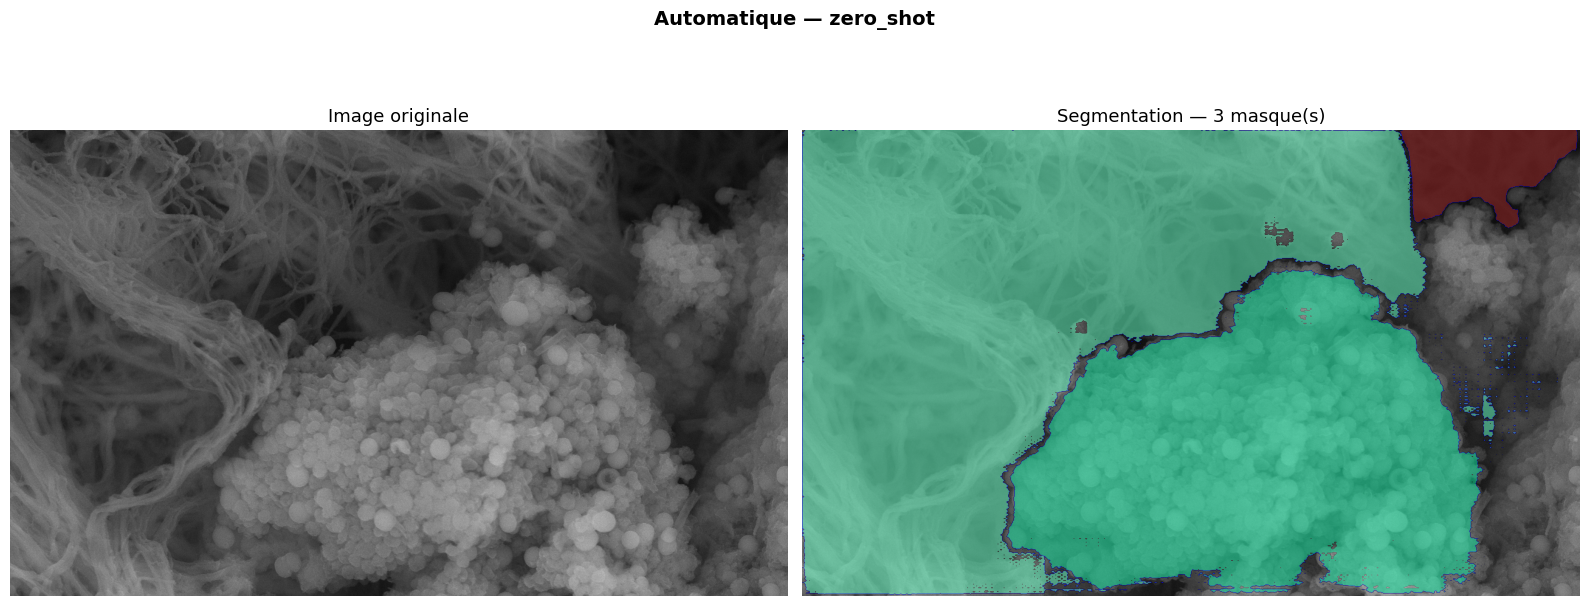

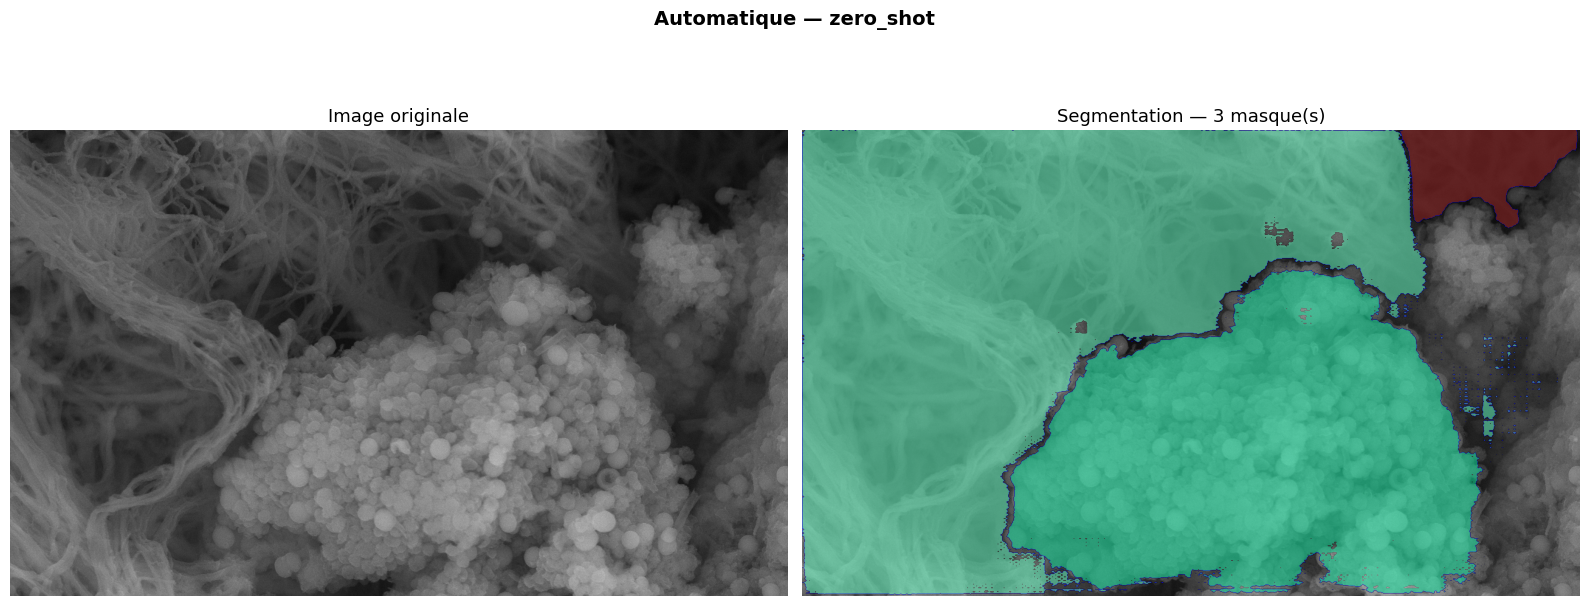

In [6]:
auto_gen = SAM2AutomaticMaskGenerator(
    model=sam2_model, points_per_side=64, pred_iou_thresh=0.8,
    stability_score_thresh=0.2, mask_threshold=0.0,
    min_mask_region_area=0, output_mode='binary_mask', multimask_output=False
)
print('Génération...')
auto_masks = auto_gen.generate(image)
print(f'{len(auto_masks)} masques')
show_masks(image, auto_masks, title=f'Automatique — {IMAGE_NAME}')

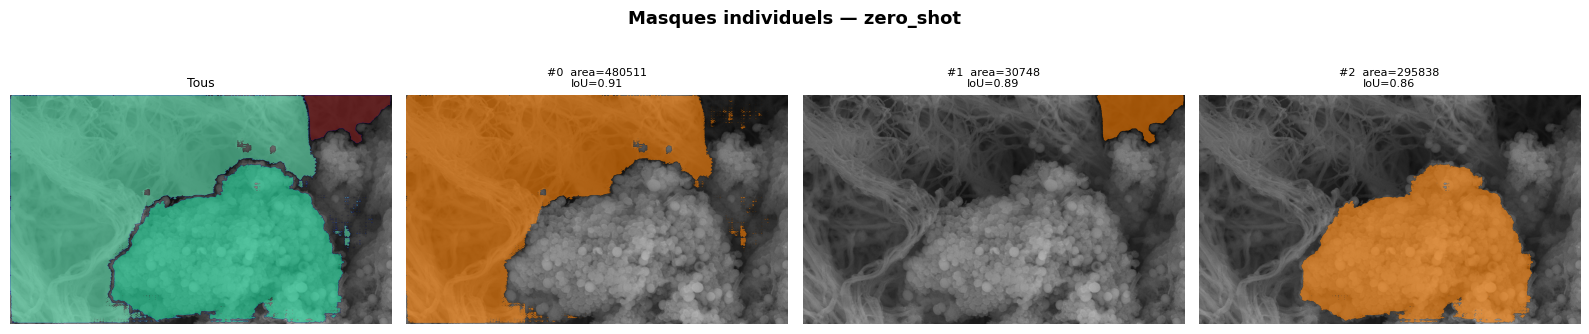

In [7]:
show_masks_grid(image, auto_masks, title=f'Masques individuels — {IMAGE_NAME}')

---
## Méthode 2 — Prompting par points (interactif)

**Clic gauche** → point d'inclusion (vert ★)  
**Clic droit** → point d'exclusion (rouge ✕)  
Bouton **Segmenter** → lance l'inférence  
Bouton **Reset** → efface tous les points

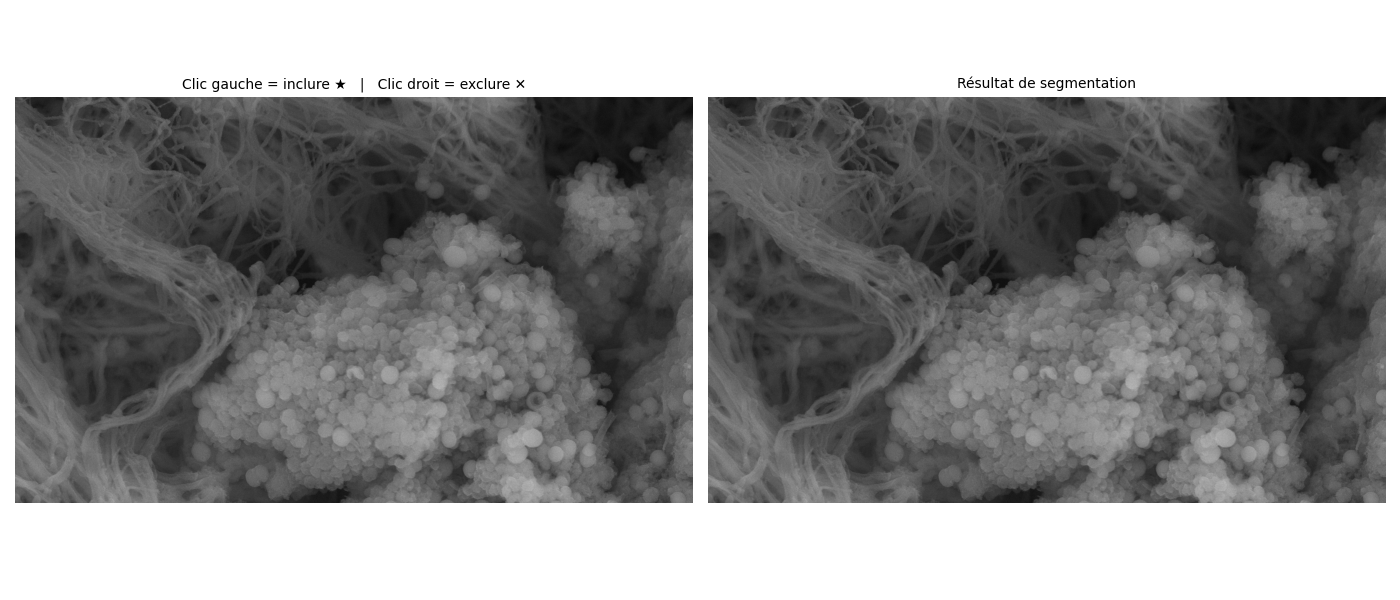

In [8]:
%matplotlib widget
import ipywidgets as widgets
from IPython.display import display

# Préparer le predictor
predictor = SAM2ImagePredictor(sam2_model)
predictor.set_image(image)


class PointPromptUI:
    """Widget interactif : clic gauche = positif, clic droit = négatif."""

    def __init__(self, image, predictor):
        self.image = image
        self.predictor = predictor
        self.coords = []
        self.labels = []

        self.fig, self.axes = plt.subplots(1, 2, figsize=(14, 6))
        self.fig.canvas.header_visible = False

        self.axes[0].imshow(self.image)
        self.axes[0].set_title('Clic gauche = inclure ★   |   Clic droit = exclure ✕', fontsize=10)
        self.axes[0].axis('off')

        self.axes[1].imshow(self.image)
        self.axes[1].set_title('Résultat de segmentation', fontsize=10)
        self.axes[1].axis('off')

        self.fig.tight_layout()

        self.btn_seg   = widgets.Button(description='⚡ Segmenter',
                                        button_style='success', layout=widgets.Layout(width='160px'))
        self.btn_reset = widgets.Button(description='🗑 Reset',
                                        button_style='danger',  layout=widgets.Layout(width='120px'))
        self.btn_undo  = widgets.Button(description='↩ Annuler',
                                        button_style='warning', layout=widgets.Layout(width='120px'))
        self.status = widgets.Label(value="Cliquez sur l'image pour poser des points.")

        self.btn_seg.on_click(self._on_segment)
        self.btn_reset.on_click(self._on_reset)
        self.btn_undo.on_click(self._on_undo)

        self.fig.canvas.mpl_connect('button_press_event', self._on_click)

        toolbar = widgets.HBox([self.btn_seg, self.btn_undo, self.btn_reset, self.status])
        display(widgets.VBox([self.fig.canvas, toolbar]))

    def _on_click(self, event):
        if event.inaxes != self.axes[0]:
            return
        x, y = int(round(event.xdata)), int(round(event.ydata))
        label = 1 if event.button == 1 else 0
        self.coords.append([x, y])
        self.labels.append(label)
        self._redraw_points()
        kind = 'positif' if label == 1 else 'négatif'
        self.status.value = f"Point {kind} ajouté en ({x}, {y})  —  total: {len(self.coords)} pts"

    def _redraw_points(self):
        for artist in list(self.axes[0].lines):
            artist.remove()
        for (x, y), lbl in zip(self.coords, self.labels):
            self.axes[0].plot(x, y, '*' if lbl == 1 else 'x',
                              color='lime' if lbl == 1 else 'red',
                              markersize=14, markeredgewidth=2, zorder=5)
        self.fig.canvas.draw_idle()

    def _on_segment(self, _):
        if not self.coords:
            self.status.value = "⚠ Aucun point — cliquez d'abord sur l'image."
            return
        self.status.value = 'Segmentation en cours...'
        masks, scores, _ = self.predictor.predict(
            point_coords=np.array(self.coords),
            point_labels=np.array(self.labels),
            multimask_output=True
        )
        # predictor.predict retourne (N, H, W) en bool ou float32 selon la version
        masks_bool = [m.astype(bool) for m in masks]
        best = int(np.argmax(scores))
        self._draw_result(masks_bool, scores, best)
        self.status.value = (
            f'✓ {len(masks_bool)} masques  |  meilleur: #{best}  '
            f'IoU={scores[best]:.3f}  |  scores={scores.round(3).tolist()}'
        )

    def _draw_result(self, masks_bool, scores, best_idx):
        self.axes[1].cla()
        self.axes[1].imshow(self.image)
        colors = [[0.1, 0.6, 1.0], [0.9, 0.4, 0.1], [0.2, 0.85, 0.3]]

        # Autres masques en arrière-plan (transparence faible)
        for i, mask in enumerate(masks_bool):
            if i == best_idx:
                continue
            ov = np.zeros((*self.image.shape[:2], 4), np.float32)
            ov[mask] = colors[i % 3] + [0.20]
            self.axes[1].imshow(ov)

        # Meilleur masque en avant-plan
        ov_best = np.zeros((*self.image.shape[:2], 4), np.float32)
        ov_best[masks_bool[best_idx]] = colors[best_idx % 3] + [0.60]
        self.axes[1].imshow(ov_best)

        # Points
        for (x, y), lbl in zip(self.coords, self.labels):
            self.axes[1].plot(x, y, '*' if lbl == 1 else 'x',
                              color='lime' if lbl == 1 else 'red',
                              markersize=12, markeredgewidth=2, zorder=5)

        autres = [f'{s:.2f}' for j, s in enumerate(scores) if j != best_idx]
        self.axes[1].set_title(
            f'Masque #{best_idx} (meilleur)  IoU={scores[best_idx]:.3f}  |  autres: {autres}',
            fontsize=9)
        self.axes[1].axis('off')
        self.fig.canvas.draw_idle()

    def _on_reset(self, _):
        self.coords.clear()
        self.labels.clear()
        self._redraw_points()
        self.axes[1].cla()
        self.axes[1].imshow(self.image)
        self.axes[1].set_title('Résultat de segmentation', fontsize=10)
        self.axes[1].axis('off')
        self.fig.canvas.draw_idle()
        self.status.value = 'Points effacés.'

    def _on_undo(self, _):
        if self.coords:
            self.coords.pop()
            self.labels.pop()
            self._redraw_points()
            self.status.value = f'Dernier point supprimé  —  {len(self.coords)} pts restants'


ui = PointPromptUI(image, predictor)

In [9]:
# ← Exécuter APRÈS avoir posé au moins un point positif dans le widget ci-dessus
pos_pts = [(x, y) for (x, y), l in zip(ui.coords, ui.labels) if l == 1]
if pos_pts:
    CLICK_X, CLICK_Y = pos_pts[0]
    print(f'✓ Premier point positif : ({CLICK_X}, {CLICK_Y})  — utilisé dans toutes les explorations')
else:
    CLICK_X, CLICK_Y = w // 2, h // 2
    print(f'⚠ Aucun point positif dans le widget — fallback centre ({CLICK_X},{CLICK_Y})')

✓ Premier point positif : (436, 599)  — utilisé dans toutes les explorations


---
## Exploration 1 — Les 3 candidats (multimask_output=True)

SAM génère toujours **3 masques** pour un clic donné, classés du plus précis au plus large.  
On voit ici les 3 propositions et leur score IoU prédit — utile pour comprendre l'ambiguïté du modèle.

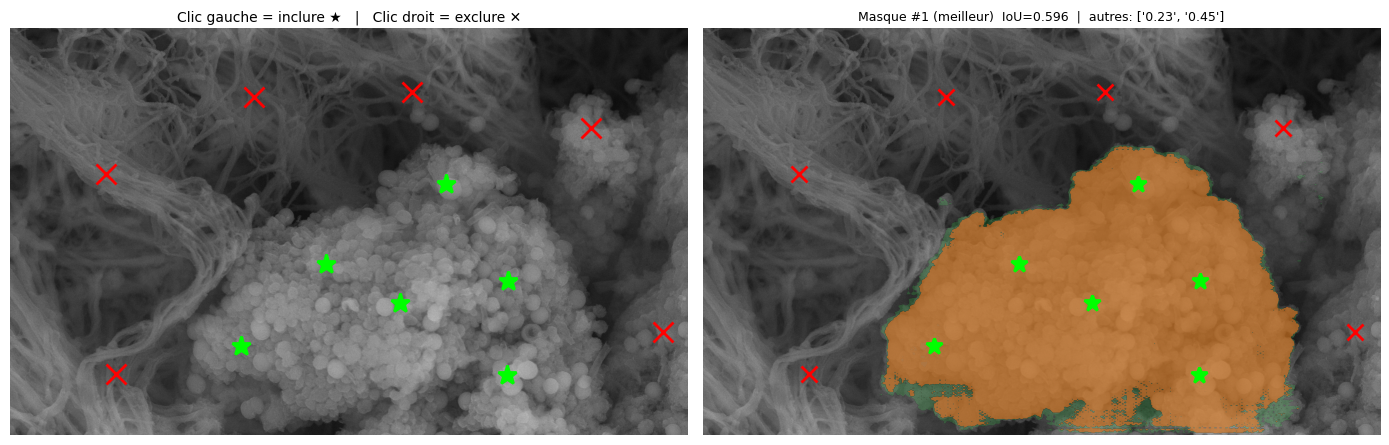

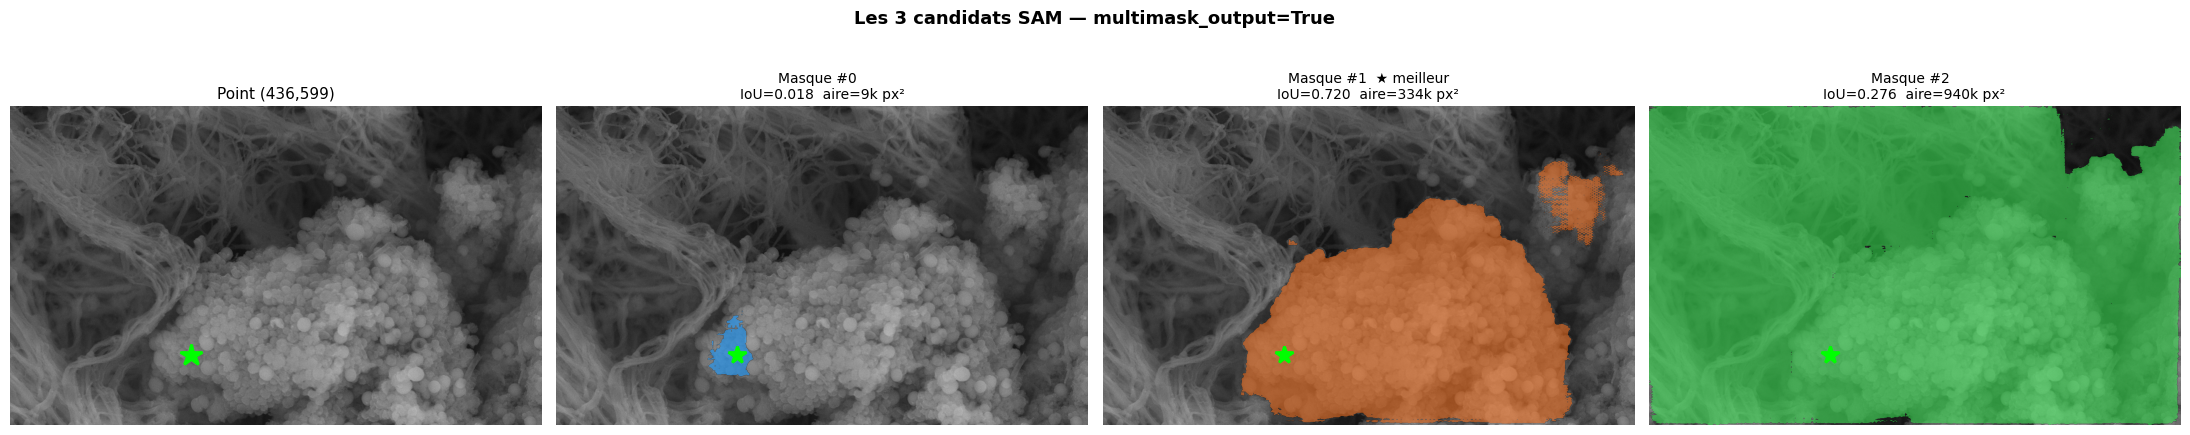

Scores : [0.017999999225139618, 0.7200000286102295, 0.2759999930858612]


In [10]:
%matplotlib inline

masks, scores, _ = predictor.predict(
    point_coords=np.array([[CLICK_X, CLICK_Y]]),
    point_labels=np.array([1]),
    multimask_output=True
)
best = int(np.argmax(scores))

colors = [[0.1, 0.6, 1.0], [0.9, 0.4, 0.1], [0.2, 0.85, 0.3]]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].imshow(image)
axes[0].plot(CLICK_X, CLICK_Y, '*', color='lime', markersize=16, markeredgewidth=2)
axes[0].set_title(f'Point ({CLICK_X},{CLICK_Y})', fontsize=11)
axes[0].axis('off')

for i in range(3):
    ov = np.zeros((*image.shape[:2], 4), np.float32)
    ov[masks[i].astype(bool)] = colors[i] + [0.60]
    axes[i+1].imshow(image)
    axes[i+1].imshow(ov)
    axes[i+1].plot(CLICK_X, CLICK_Y, '*', color='lime', markersize=13, markeredgewidth=2)
    label = '★ meilleur' if i == best else ''
    axes[i+1].set_title(
        f'Masque #{i}  {label}\nIoU={scores[i]:.3f}  aire={masks[i].astype(bool).sum()//1000}k px²',
        fontsize=10
    )
    axes[i+1].axis('off')

plt.suptitle('Les 3 candidats SAM — multimask_output=True', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Scores : {scores.round(3).tolist()}')

---
## Exploration 2 — Heatmap de confiance (logits bruts)

`predictor.predict` retourne aussi les **logits** : la carte de confiance brute avant binarisation.  
Ici on applique une sigmoid pour avoir une probabilité P(pixel ∈ masque) entre 0 et 1.  
Les zones chaudes = le modèle est sûr ; les zones froides = le modèle hésite.

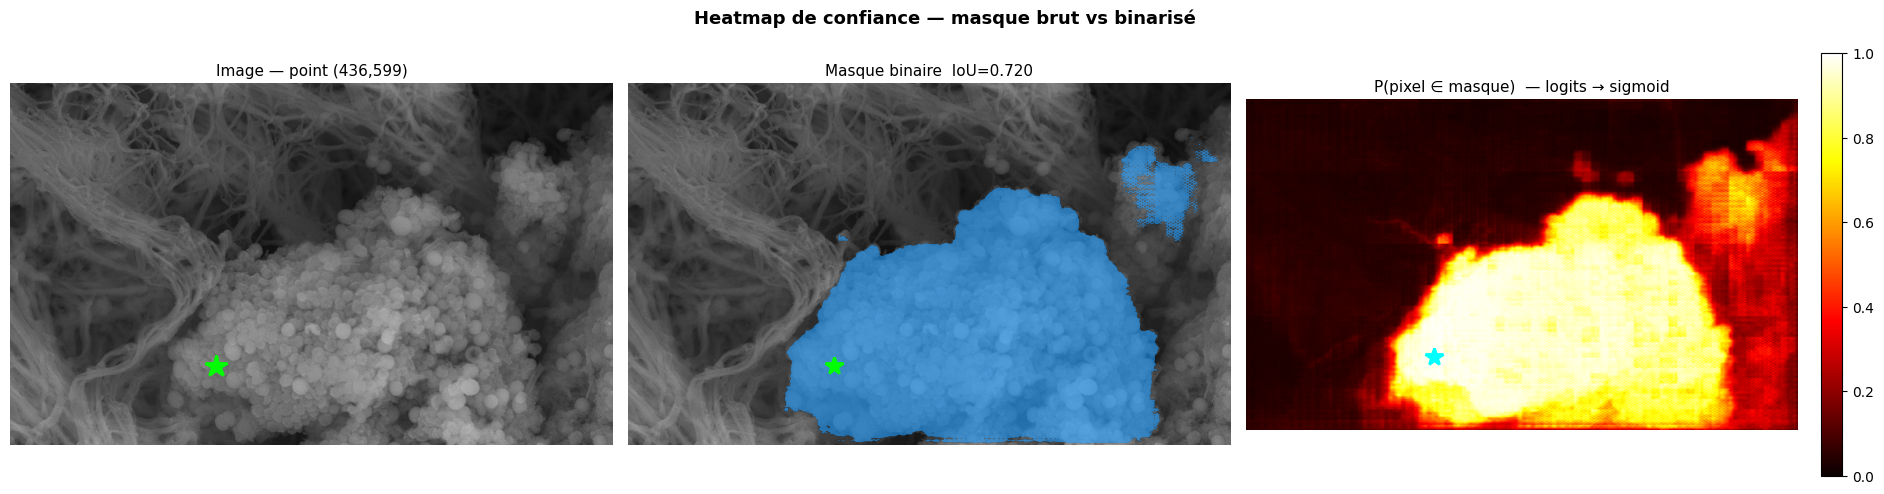

Prob min=0.012  max=0.996  moy(dans masque)=0.859


In [11]:
masks, scores, logits = predictor.predict(
    point_coords=np.array([[CLICK_X, CLICK_Y]]),
    point_labels=np.array([1]),
    multimask_output=True
)
best = int(np.argmax(scores))

logit_map = logits[best]
if logit_map.ndim == 3:
    logit_map = logit_map[0]
prob_map = 1 / (1 + np.exp(-logit_map.astype(np.float32)))  # sigmoid → [0,1]

# logits sont à 256×256 (résolution interne SAM), on upscale à la taille image
prob_map = cv2.resize(prob_map, (w, h), interpolation=cv2.INTER_LINEAR)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

axes[0].imshow(image)
axes[0].plot(CLICK_X, CLICK_Y, '*', color='lime', markersize=16, markeredgewidth=2)
axes[0].set_title(f'Image — point ({CLICK_X},{CLICK_Y})', fontsize=11)
axes[0].axis('off')

ov = np.zeros((*image.shape[:2], 4), np.float32)
ov[masks[best].astype(bool)] = [0.1, 0.6, 1.0, 0.6]
axes[1].imshow(image)
axes[1].imshow(ov)
axes[1].plot(CLICK_X, CLICK_Y, '*', color='lime', markersize=13, markeredgewidth=2)
axes[1].set_title(f'Masque binaire  IoU={scores[best]:.3f}', fontsize=11)
axes[1].axis('off')

im = axes[2].imshow(prob_map, cmap='hot', vmin=0, vmax=1)
axes[2].plot(CLICK_X, CLICK_Y, '*', color='cyan', markersize=13, markeredgewidth=2)
axes[2].set_title('P(pixel ∈ masque)  — logits → sigmoid', fontsize=11)
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle('Heatmap de confiance — masque brut vs binarisé', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Prob min={prob_map.min():.3f}  max={prob_map.max():.3f}  '
      f'moy(dans masque)={prob_map[masks[best].astype(bool)].mean():.3f}')

---
## Exploration 3 — Effet des points négatifs

On part d'un seul point positif, puis on ajoute progressivement des points d'exclusion.  
Le widget PointPromptUI ci-dessus sauvegarde ses clics dans `ui.coords` / `ui.labels` — on les réutilise ici.  
Si vous n'en avez pas, des exemples hardcodés sont utilisés.

Points du widget : 6 positifs, 6 négatifs


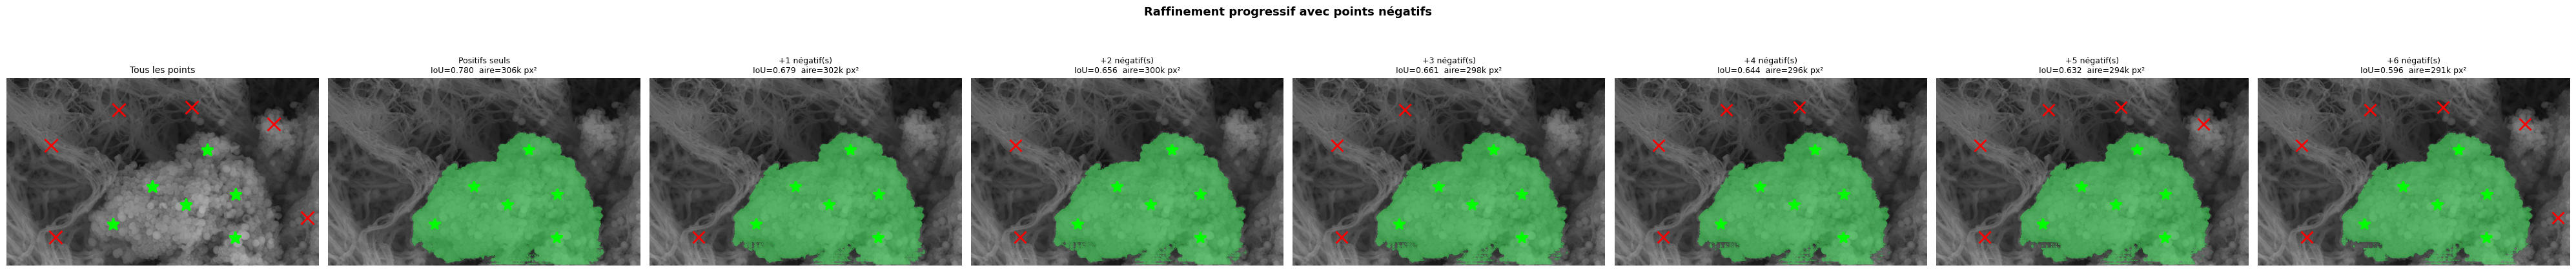

In [12]:
# Récupère les points du widget ou utilise des exemples
if hasattr(ui, 'coords') and len(ui.coords) >= 2:
    all_coords = np.array(ui.coords)
    all_labels = np.array(ui.labels)
    pos_idx = np.where(all_labels == 1)[0]
    neg_idx = np.where(all_labels == 0)[0]
    print(f'Points du widget : {len(pos_idx)} positifs, {len(neg_idx)} négatifs')
else:
    # Exemples hardcodés : 1 positif au centre + 2 négatifs à droite et en bas
    all_coords = np.array([[CLICK_X, CLICK_Y],
                           [min(CLICK_X + 40, w-1), CLICK_Y],
                           [CLICK_X, min(CLICK_Y + 40, h-1)]])
    all_labels = np.array([1, 0, 0])
    print(f'Exemples hardcodés utilisés')
    pos_idx = np.array([0])
    neg_idx = np.array([1, 2])

# Construire les étapes : pos seul, pos+1neg, pos+tous négatifs
steps = []
pos_coords = all_coords[pos_idx]
pos_labels = np.ones(len(pos_idx), dtype=int)
steps.append(('Positifs seuls', pos_coords, pos_labels))

for k in range(1, len(neg_idx) + 1):
    c = np.vstack([pos_coords, all_coords[neg_idx[:k]]])
    l = np.concatenate([pos_labels, np.zeros(k, dtype=int)])
    steps.append((f'+{k} négatif(s)', c, l))

cols = len(steps) + 1
fig, axes = plt.subplots(1, cols, figsize=(5 * cols, 5))
axes[0].imshow(image)
for (x, y), lbl in zip(all_coords, all_labels):
    axes[0].plot(x, y, '*' if lbl == 1 else 'x',
                 color='lime' if lbl == 1 else 'red',
                 markersize=14, markeredgewidth=2)
axes[0].set_title('Tous les points', fontsize=10)
axes[0].axis('off')

for i, (label, coords, labels) in enumerate(steps):
    masks_s, scores_s, _ = predictor.predict(
        point_coords=coords, point_labels=labels, multimask_output=True
    )
    best_s = int(np.argmax(scores_s))
    mask_s = masks_s[best_s].astype(bool)
    ov = np.zeros((*image.shape[:2], 4), np.float32)
    ov[mask_s] = [0.2, 0.8, 0.3, 0.6]
    axes[i+1].imshow(image)
    axes[i+1].imshow(ov)
    for (x, y), lbl in zip(coords, labels):
        axes[i+1].plot(x, y, '*' if lbl == 1 else 'x',
                       color='lime' if lbl == 1 else 'red',
                       markersize=13, markeredgewidth=2, zorder=5)
    axes[i+1].set_title(
        f'{label}\nIoU={scores_s[best_s]:.3f}  aire={mask_s.sum()//1000}k px²',
        fontsize=9)
    axes[i+1].axis('off')

plt.suptitle('Raffinement progressif avec points négatifs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Exploration 4 — Sensibilité à la position du clic

On balaie une grille 3×3 de positions sur l'image et on observe comment la segmentation change.  
Ça montre si le modèle segmente par région cohérente ou par texture locale.

In [ ]:
GRID_ROWS, GRID_COLS = 3, 3
ys = np.linspace(h * 0.15, h * 0.85, GRID_ROWS).astype(int)
xs = np.linspace(w * 0.15, w * 0.85, GRID_COLS).astype(int)

fig, axes = plt.subplots(GRID_ROWS, GRID_COLS, figsize=(5 * GRID_COLS, 4.5 * GRID_ROWS))
fig.suptitle(f'Grille de clics {GRID_ROWS}×{GRID_COLS} — {IMAGE_NAME}',
             fontsize=13, fontweight='bold')

for ri, y in enumerate(ys):
    for ci, x in enumerate(xs):
        masks_g, scores_g, _ = predictor.predict(
            point_coords=np.array([[x, y]]),
            point_labels=np.array([1]),
            multimask_output=True
        )
        best_g = int(np.argmax(scores_g))
        mask_g = masks_g[best_g].astype(bool)
        ov = np.zeros((*image.shape[:2], 4), np.float32)
        ov[mask_g] = [0.9, 0.4, 0.1, 0.55]
        ax = axes[ri][ci]
        ax.imshow(image)
        ax.imshow(ov)
        ax.plot(x, y, '*', color='lime', markersize=13, markeredgewidth=2, zorder=5)
        ax.set_title(f'({x},{y})  IoU={scores_g[best_g]:.2f}\naire={mask_g.sum()//1000}k px²',
                     fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.show()

---
## Exploration 5 — Comparaison des 3 checkpoints (même clic)

Même point → SAM-2.1 original vs TextureSAM η≤0.3 vs TextureSAM η≤1.  
Permet de voir si le fine-tuning sur les textures change la segmentation pour ce type d'image.

Chargement SAM-2.1 original...
Chargement TextureSAM η≤0.3...
Fine-tuned weights  missing=0 unexpected=0
Chargement TextureSAM η≤1...
Fine-tuned weights  missing=0 unexpected=0


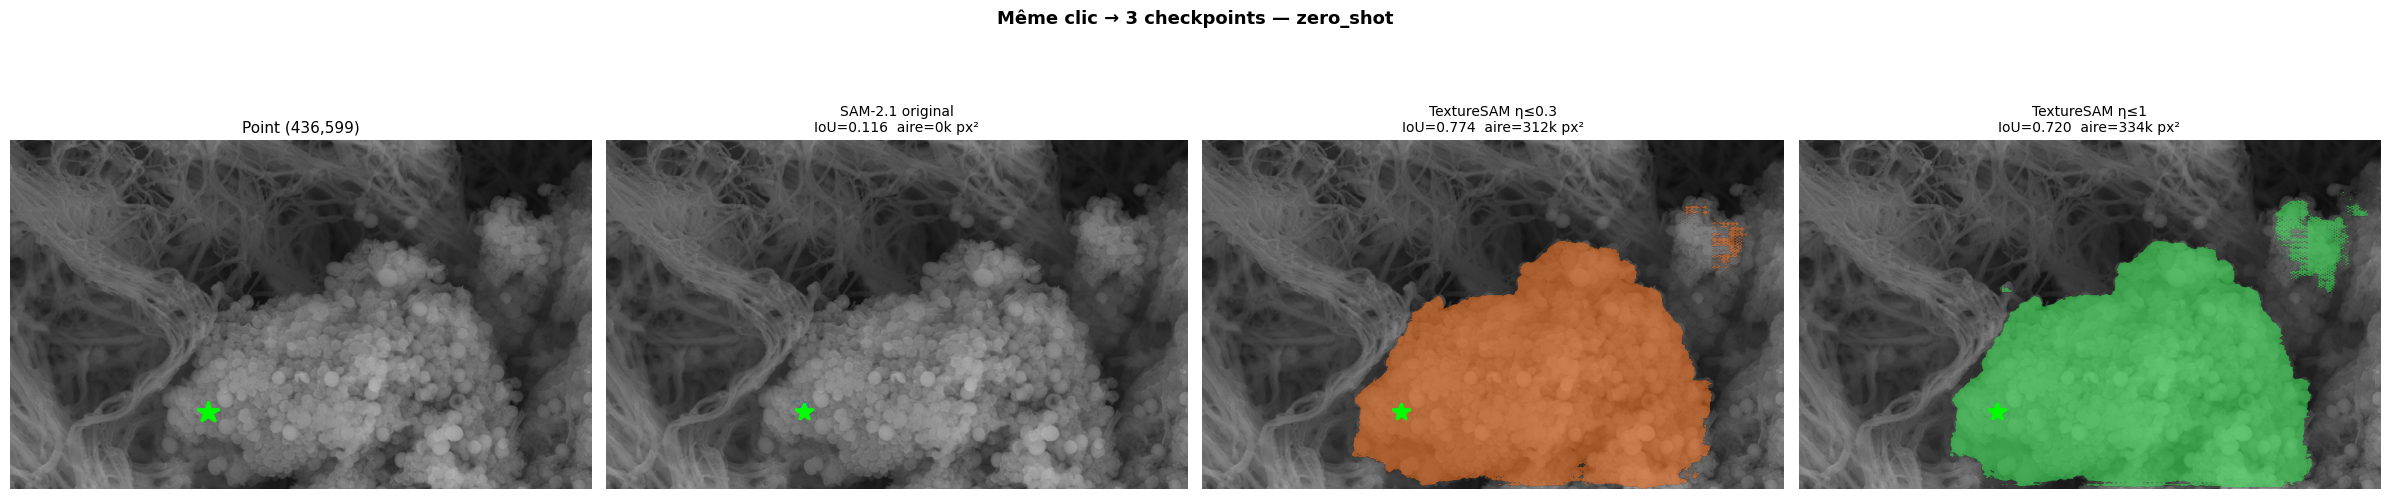

Terminé.


In [13]:
CKPTS = {
    'SAM-2.1 original': 'checkpoints/sam2.1_hiera_small',
    'TextureSAM η≤0.3': 'checkpoints/sam2.1_hiera_small_0.3',
    'TextureSAM η≤1':   'checkpoints/sam2.1_hiera_small_1.pt',
}
COLORS_CK = [[0.1, 0.6, 1.0], [0.9, 0.4, 0.1], [0.2, 0.85, 0.3]]

fig, axes = plt.subplots(1, len(CKPTS) + 1, figsize=(6 * (len(CKPTS) + 1), 6))
axes[0].imshow(image)
axes[0].plot(CLICK_X, CLICK_Y, '*', color='lime', markersize=16, markeredgewidth=2)
axes[0].set_title(f'Point ({CLICK_X},{CLICK_Y})', fontsize=11)
axes[0].axis('off')

for i, (name, ckpt) in enumerate(CKPTS.items()):
    print(f'Chargement {name}...')
    m = load_model(ckpt)
    pred = SAM2ImagePredictor(m)
    pred.set_image(image)
    masks_c, scores_c, _ = pred.predict(
        point_coords=np.array([[CLICK_X, CLICK_Y]]),
        point_labels=np.array([1]),
        multimask_output=True
    )
    best_c = int(np.argmax(scores_c))
    mask_c = masks_c[best_c].astype(bool)
    ov = np.zeros((*image.shape[:2], 4), np.float32)
    ov[mask_c] = COLORS_CK[i] + [0.60]
    axes[i+1].imshow(image)
    axes[i+1].imshow(ov)
    axes[i+1].plot(CLICK_X, CLICK_Y, '*', color='lime', markersize=13, markeredgewidth=2)
    axes[i+1].set_title(
        f'{name}\nIoU={scores_c[best_c]:.3f}  aire={mask_c.sum()//1000}k px²',
        fontsize=10)
    axes[i+1].axis('off')

plt.suptitle(f'Même clic → 3 checkpoints — {IMAGE_NAME}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Terminé.')